
Summary:
 qualified_for_europe  club_seasons  avg_current_xpts  avg_next_xpts  avg_xpts_change  median_xpts_change  avg_current_position  avg_next_position                      group
                    0            85         45.272922      45.457081         0.184159             -0.7249             13.482353          13.505882 Did not qualify for Europe
                    1            13         59.390300      54.146869        -5.243431             -2.9793              6.076923           8.615385       Qualified for Europe

Europe qualifier examples:
              team_name  year understat_season  position    xpts  next_position  next_xpts  xpts_change_next_season
Wolverhampton Wanderers  2019          2019/20         7 63.8213           13.0    44.2578                 -19.5635
              Leicester  2020          2020/21         5 59.7490            8.0    42.3123                 -17.4367
               Brighton  2022          2022/23         6 70.8574           13.0    54.4324  

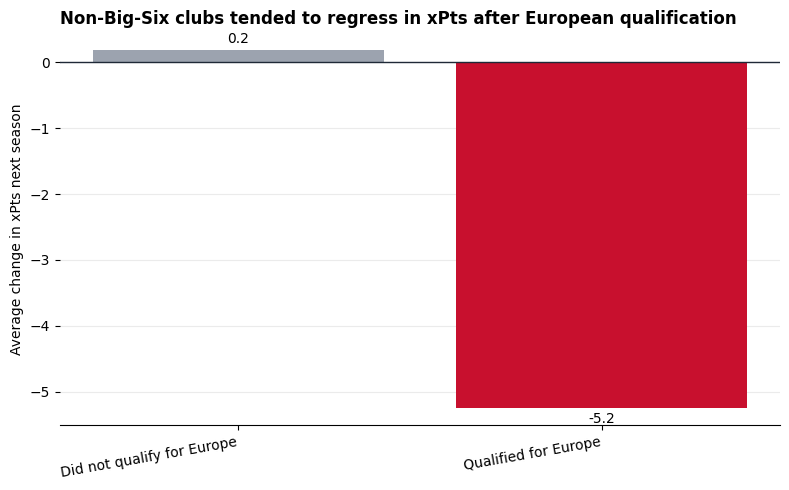

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


DATA_PATH = Path("../data/master/modelling_features.csv")
OUTPUT_DIR = Path("../data/outputs/europe_effect_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BIG_SIX = {
    "Arsenal",
    "Chelsea",
    "Liverpool",
    "Manchester City",
    "Manchester United",
    "Tottenham",
}

df = pd.read_csv(DATA_PATH)

# Non-Big-Six only
df = df[~df["team_name"].isin(BIG_SIX)].copy()

# Make sure data is sorted correctly
df = df.sort_values(["team_name", "year"])

# Define Europe qualification.
# If you already have qualified_for_europe, use that.
# Otherwise, approximate using league position <= 7.
if "qualified_for_europe" not in df.columns:
    df["qualified_for_europe"] = (df["position"] <= 7).astype(int)

# Add next-season xPts and position
df["next_xpts"] = df.groupby("team_name")["xpts"].shift(-1)
df["next_position"] = df.groupby("team_name")["position"].shift(-1)

# Change in xPts after current season
df["xpts_change_next_season"] = df["next_xpts"] - df["xpts"]

# Keep rows where next season exists
analysis = df.dropna(
    subset=[
        "xpts",
        "next_xpts",
        "xpts_change_next_season",
        "qualified_for_europe",
    ]
).copy()

# Compare European qualifiers vs non-qualifiers
summary = (
    analysis.groupby("qualified_for_europe")
    .agg(
        club_seasons=("team_name", "count"),
        avg_current_xpts=("xpts", "mean"),
        avg_next_xpts=("next_xpts", "mean"),
        avg_xpts_change=("xpts_change_next_season", "mean"),
        median_xpts_change=("xpts_change_next_season", "median"),
        avg_current_position=("position", "mean"),
        avg_next_position=("next_position", "mean"),
    )
    .reset_index()
)

summary["group"] = summary["qualified_for_europe"].map(
    {0: "Did not qualify for Europe", 1: "Qualified for Europe"}
)

summary.to_csv(OUTPUT_DIR / "europe_xpts_effect_summary.csv", index=False)

print("\nSummary:")
print(summary.to_string(index=False))

# Club-level examples
europe_examples = analysis[analysis["qualified_for_europe"] == 1][
    [
        "team_name",
        "year",
        "understat_season",
        "position",
        "xpts",
        "next_position",
        "next_xpts",
        "xpts_change_next_season",
    ]
].copy()

europe_examples = europe_examples.sort_values("xpts_change_next_season")

europe_examples.to_csv(
    OUTPUT_DIR / "non_big_six_europe_qualifiers_xpts_change.csv",
    index=False,
)

print("\nEurope qualifier examples:")
print(europe_examples.to_string(index=False))

# Plot
plot_df = summary.copy()

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#9CA3AF", "#C8102E"]

ax.bar(
    plot_df["group"],
    plot_df["avg_xpts_change"],
    color=colors,
)

ax.axhline(0, color="#1F2937", linewidth=1)

ax.set_title(
    "Non-Big-Six clubs tended to regress in xPts after European qualification",
    loc="left",
    fontweight="bold",
)
ax.set_ylabel("Average change in xPts next season")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.xticks(rotation=10, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "europe_xpts_change_bar_chart.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()